$$\def\data{ {\bf d}_\rm{obs}}
\def\vec{\bf}
\def\m{ {\bf m}}
\def\map{{\bf m}_{\text{MAP}}}
\def\postcov{{\bf \Gamma}_{\text{post}}}
\def\prcov{{\bf \Gamma}_{\text{prior}}}
\def\matrix{\bf}
\def\Hmisfit{{\bf H}_{\text{misfit}}}
\def\diag{\operatorname{diag}}
\def\Vr{{\matrix V}_r}
$$
# Sampling the posterior with MCMC
## Bayesian quantification of the uncertainty in the coefficient field of an elliptic PDE

This tutorial solves the subsurface flow inverse problem of tutorial 3 once more, then goes
past the Laplace approximation: it samples the full posterior with Markov chain Monte Carlo
(MCMC) and estimates the posterior expectation of a quantity of interest.

### Bayes' Theorem:

The posterior probability distribution combines the prior pdf $\pi_{\text{prior}}(\m)$ over
the parameter space with a likelihood pdf $\pi_{\text{like}}(\data \; | \; \m)$, which
represents the probability that a given set of parameters $\m$ might give rise to the
observed data $\data \in \mathbb{R}^q$:

$$ \pi_{\text{post}}(\m | \data) \propto \pi_{\text{prior}}(\m) \pi_{\text{like}}(\data | \m). $$

### Gaussian prior and noise:

The prior is Gaussian with mean $\m_{\rm prior}$ and covariance $\prcov$, the discretization
of $\mathcal{A}^{-2} = (-\gamma \nabla\cdot(\Theta\nabla) + \delta I)^{-2}$, and the noise is
additive and Gaussian,

$$ \data = {\bf f}(\m) + {\bf e }, \;\;\; {\bf e} \sim \mathcal{N}({\bf 0}, {\bf \Gamma}_{\text{noise}} ), $$

so that

$$ \pi_{\text{post}}(\m \; | \; \data) \propto \exp \left( - \tfrac{1}{2} \parallel {\bf f}(\m) - \data \parallel^{2}_{{\bf \Gamma}_{\text{noise}}^{-1}} \! - \tfrac{1}{2}\parallel \m - \m_{\rm prior} \parallel^{2}_{\prcov^{-1}} \right). $$

### The Gaussian approximation of the posterior: $\mathcal{N}({\vec \map},\bf \postcov)$

The MAP point $\map$ minimizes the negative log posterior, and the covariance of the
Laplace approximation is the inverse Hessian there,
$\postcov = \left(\Hmisfit(\map) + \prcov^{-1} \right)^{-1}$. From the generalized
eigenvalue problem $\Hmisfit {\matrix V} = \prcov^{-1} {\matrix V} {\matrix \Lambda}$, a
low-rank approximation keeps the $r$ eigenvalues that matter and gives

$$ \postcov \approx \prcov - \Vr {\matrix{D}}_r \Vr^T, \qquad {\matrix{D}}_r :=\diag(\lambda_i/(\lambda_i+1)), $$

which can be applied, factorized and sampled at the cost of a few prior solves.

### Markov chain Monte Carlo

The Laplace approximation is exact only when the parameter-to-observable map is linear;
here it is not. To compute expectations under the posterior itself, a Markov chain
proposes parameter fields and accepts or rejects each one with a Metropolis-Hastings test,
so that in the long run the chain visits fields in proportion to their posterior
probability. We use the generalized preconditioned Crank-Nicolson (gpCN) proposal, which
draws its perturbations from the Laplace approximation: because the proposal already has
the posterior's Gaussian shape, its acceptance rate does not collapse as the mesh is
refined, and the step size $s$ trades acceptance for mixing.

Every sample costs one forward solve, and successive samples are correlated. The number
that says what a chain is worth is the *effective sample size*, the chain length divided by
the integrated autocorrelation time.

## This tutorial shows:

- the MAP point and the Laplace approximation of the posterior (as in tutorial 3)
- a quantity of interest written as a density, and evaluated along the chain
- a gpCN chain with the Laplace approximation as its proposal
- trace plot, histogram, autocorrelation and effective sample size of the chain

## Mathematical tools used:

- Finite element method
- Derivation of gradient and Hessian via the adjoint method
- Inexact Newton-CG and Armijo line search
- Bayes' formula and randomized eigensolvers
- Markov chain Monte Carlo

## List of software used:

- [MFEM](https://mfem.org) through [PyMFEM](https://github.com/mfem/PyMFEM), a parallel finite element library
- [hypre](https://github.com/hypre-space/hypre), for scalable preconditioners
- [JAX](https://docs.jax.dev), for automatic differentiation
- [Matplotlib](https://matplotlib.org) and [NumPy](https://numpy.org)

## 1. Load modules

In [1]:
import math
import os
import sys
import time

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb, STATE, PARAMETER, ADJOINT

import jax.numpy as jnp

mfem.Hypre.Init()
comm = MPI.COMM_WORLD

## 2. Generate the true parameter

This function generates a random field with a prescribed anisotropic covariance function.

In [2]:
def true_model(prior):
    noise = prior.noise_vector()
    prior.sample_noise(1.0, noise)
    mtrue = prior.mean.duplicate()
    prior.sample(noise, mtrue)
    return mtrue

## 3. Set up the mesh and finite element spaces

A P2 space for the *state* and *adjoint* variables and P1 for the *parameter*. The mesh is
coarser than in tutorial 3 (32 by 32 instead of 64 by 64) so that the chain below, one
forward solve per sample, runs in a few minutes.

In [3]:
nx = ny = 32
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(nx, ny, mfem.Element.TRIANGLE))
Vh2 = hm.FunctionSpace.H1(mesh, 2)
Vh1 = hm.FunctionSpace.H1(mesh, 1)
Vh = [Vh2, Vh1, Vh2]
print("Number of dofs: STATE={0}, PARAMETER={1}, ADJOINT={2}".format(
    Vh[STATE].GlobalTrueVSize(), Vh[PARAMETER].GlobalTrueVSize(), Vh[ADJOINT].GlobalTrueVSize()))

Number of dofs: STATE=4225, PARAMETER=1089, ADJOINT=4225


## 4. Set up the forward problem

In [4]:
bottom, right, top, left = 1, 2, 3, 4
bc = hm.DirichletBC(Vh[STATE], lambda x: x[1], bdr_attributes=[bottom, top])
bc0 = bc.homogeneous()

f = 0.0


def pde_varf(u, m, p, x):
    return jnp.exp(m.val) * hm.inner(u.grad, p.grad) - f * p.val


pde = hm.PDEVariationalProblem(Vh, pde_varf, bc, bc0, is_fwd_linear=True)
for attr in ("solver", "solver_fwd_inc", "solver_adj_inc"):
    setattr(pde, attr, hm.auto_solver(Vh[STATE], comm))

## 5. Set up the prior

A Gaussian prior with zero mean and covariance $\mathcal{C} = \mathcal{A}^{-2}$, with
$\mathcal{A} = -\gamma \nabla \cdot (\Theta \nabla) + \delta I$, Robin boundary conditions
and an anisotropic tensor $\Theta$, as in tutorial 3.

Prior regularization: (delta - gamma*Laplacian)^order: delta=0.5, gamma=0.1, order=2


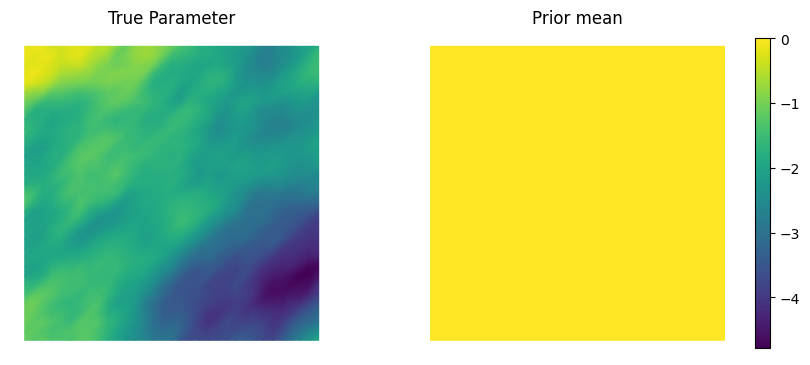

In [5]:
gamma = 0.1
delta = 0.5

theta0 = 2.0
theta1 = 0.5
alpha = math.pi / 4
sa, ca = math.sin(alpha), math.cos(alpha)
Theta = np.array([[theta0 * sa**2 + theta1 * ca**2, (theta0 - theta1) * sa * ca],
                  [(theta0 - theta1) * sa * ca, theta0 * ca**2 + theta1 * sa**2]])

prior = hm.BiLaplacianPrior(Vh[PARAMETER], gamma, delta, Theta=Theta, robin_bc=True)
hm.parRandom.set_seed(1)
mtrue = true_model(prior)

print("Prior regularization: (delta - gamma*Laplacian)^order: delta={0}, gamma={1}, order={2}".format(delta, gamma, 2))

nb.multi1_plot([(Vh[PARAMETER], mtrue), (Vh[PARAMETER], prior.mean)], ["True Parameter", "Prior mean"])
plt.show()

## 6. Set up the misfit functional and generate synthetic observations

The state is observed at `ntargets` random points, and the data are perturbed with Gaussian
noise whose standard deviation is one percent of the largest observed value.

Number of observation points: 300


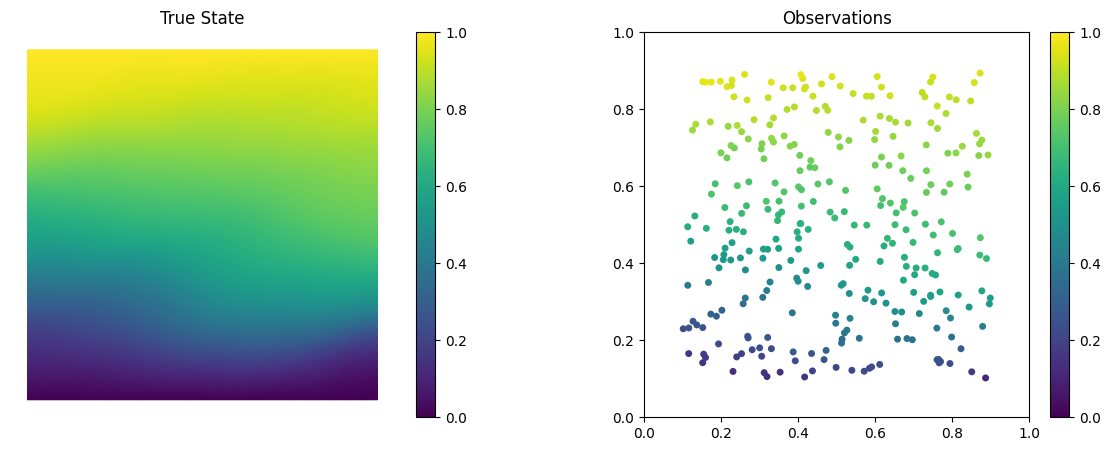

In [6]:
ntargets = 300
rel_noise = 0.01

rng = np.random.default_rng(1)
targets = rng.uniform(0.1, 0.9, [ntargets, 2])
print("Number of observation points: {0}".format(ntargets))
B = hm.assemblePointwiseObservation(Vh[STATE], targets)

utrue = pde.generate_state()
x = [utrue, mtrue, None]
pde.solveFwd(x[STATE], x)
data = B.createVecLeft()
B.mult(x[STATE], data)
MAX = data.norm("linf")
noise_std_dev = rel_noise * MAX
B.perturb(data, noise_std_dev)
misfit = hm.DiscreteStateObservation(B, data, noise_std_dev**2)

observed = B.gather(data)
vmax = max(utrue.max(), observed.max())
vmin = min(utrue.min(), observed.min())

plt.figure(figsize=(15, 5))
nb.plot(Vh[STATE], utrue, mytitle="True State", subplot_loc=121, vmin=vmin, vmax=vmax)
nb.plot_pts(targets, observed, mytitle="Observations", subplot_loc=122, vmin=vmin, vmax=vmax)
plt.show()

## 7. Set up the model and test gradient and Hessian

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  2.168458e+05  1.120261e+02  2.528873e+05             -


 5.00e-01  1.083670e+05  6.043927e+01  8.812569e+04        1.0007


 2.50e-01  5.418364e+04  3.029979e+01  4.643844e+04        1.0000


 1.25e-01  2.709366e+04  1.509539e+01  3.575441e+04        0.9999


...

 7.45e-09  7.989883e-01  7.352647e-03  3.184289e+04       -2.1416


 3.73e-09  8.253555e-01  1.061354e-02  3.184289e+04       -0.0468


 1.86e-09  4.217934e+00  3.600484e-02  3.184289e+04       -2.3534


 9.31e-10  4.354652e+00  4.712534e-02  3.184289e+04       -0.0460


 4.66e-10  9.428871e+00  8.799579e-02  3.184289e+04       -1.1145


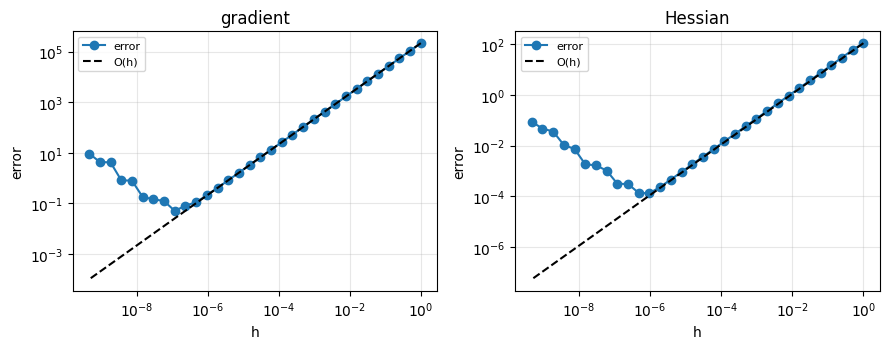

In [7]:
model = hm.Model(pde, prior, misfit)

m0 = Vh[PARAMETER].project(lambda x: np.sin(x[0]))
_ = hm.modelVerify(model, m0, plotting=True)
plt.show()

## 8. Compute the MAP point


 It cg_it            cost          misfit             reg          (g,dm)          ||g||          alpha          tolcg


  1     1    3.709665e+03    3.709315e+03    3.499556e-01   -5.627363e+04   1.535360e+05   1.000000e+00   5.000000e-01


  2     2    1.213328e+03    1.212608e+03    7.195305e-01   -5.140401e+03   2.618165e+04   1.000000e+00   4.129461e-01


  3     3    4.892207e+02    4.877436e+02    1.477103e+00   -1.451856e+03   1.143546e+04   1.000000e+00   2.729114e-01


  4     7    1.941624e+02    1.887938e+02    5.368554e+00   -5.967628e+02   4.896922e+03   1.000000e+00   1.785897e-01


...

  7    20    1.420045e+02    1.260847e+02    1.591982e+01   -1.566582e+01   7.338863e+02   1.000000e+00   6.913680e-02


  8    13    1.418138e+02    1.258984e+02    1.591541e+01   -3.803763e-01   1.498168e+02   1.000000e+00   3.123741e-02


  9    30    1.417640e+02    1.254342e+02    1.632971e+01   -9.974842e-02   7.615767e+01   1.000000e+00   2.227161e-02


 10    35    1.417639e+02    1.254378e+02    1.632615e+01   -4.605267e-05   1.297871e+00   1.000000e+00   2.907439e-03



Converged in 10 iterations.
Termination reason: Norm of the gradient less than tolerance
Final gradient norm: 0.011918988884539681
Final cost: 141.7639311044719


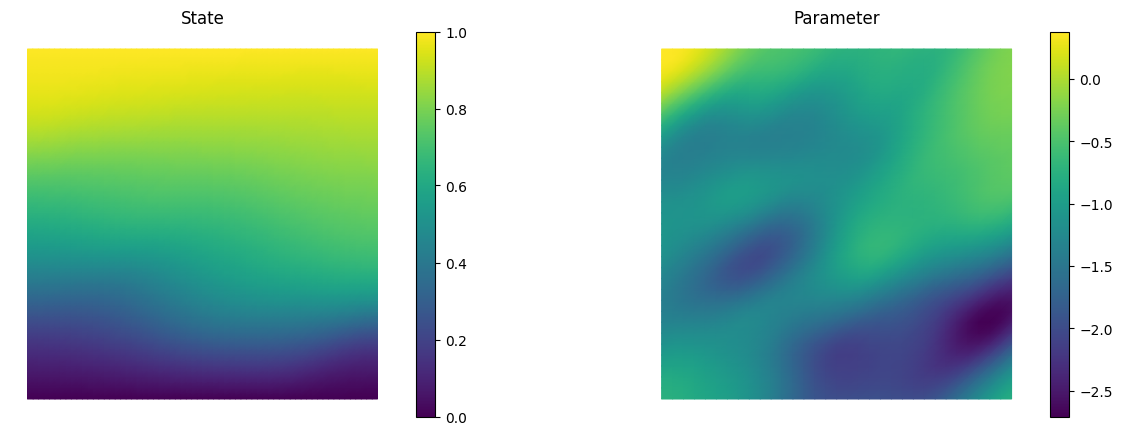

In [8]:
m = prior.mean.copy()
parameters = hm.ReducedSpaceNewtonCG_ParameterList()
parameters["rel_tolerance"] = 1e-6
parameters["abs_tolerance"] = 1e-12
parameters["max_iter"] = 25
parameters["GN_iter"] = 5
parameters["globalization"] = "LS"
parameters["LS"]["c_armijo"] = 1e-4
solver = hm.ReducedSpaceNewtonCG(model, parameters)

x = solver.solve([None, m, None])

if solver.converged:
    print("\nConverged in", solver.it, "iterations.")
else:
    print("\nNot Converged")

print("Termination reason:", solver.termination_reasons[solver.reason])
print("Final gradient norm:", solver.final_grad_norm)
print("Final cost:", solver.final_cost)

plt.figure(figsize=(15, 5))
nb.plot(Vh[STATE], x[STATE], subplot_loc=121, mytitle="State")
nb.plot(Vh[PARAMETER], x[PARAMETER], subplot_loc=122, mytitle="Parameter")
plt.show()

## 9. Compute the low rank Gaussian approximation of the posterior

We use the *double pass* algorithm to compute a low-rank decomposition of the Hessian
misfit, $\Hmisfit {\bf u} = \lambda \prcov^{-1} {\bf u}$. The effective rank of the Hessian
misfit is the number of eigenvalues above the red line ($y=1$).

Double Pass Algorithm. Requested eigenvectors: 50; Oversampling 20.


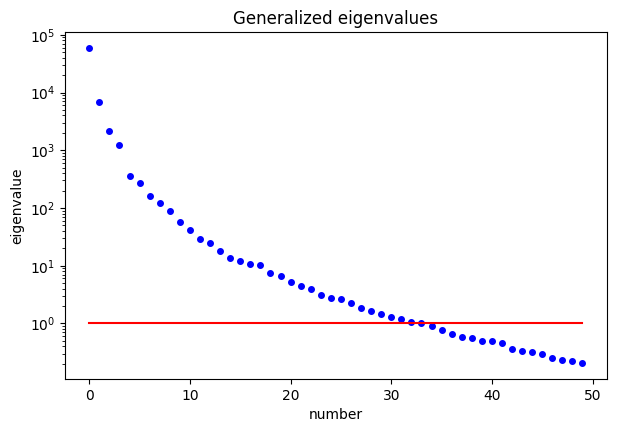

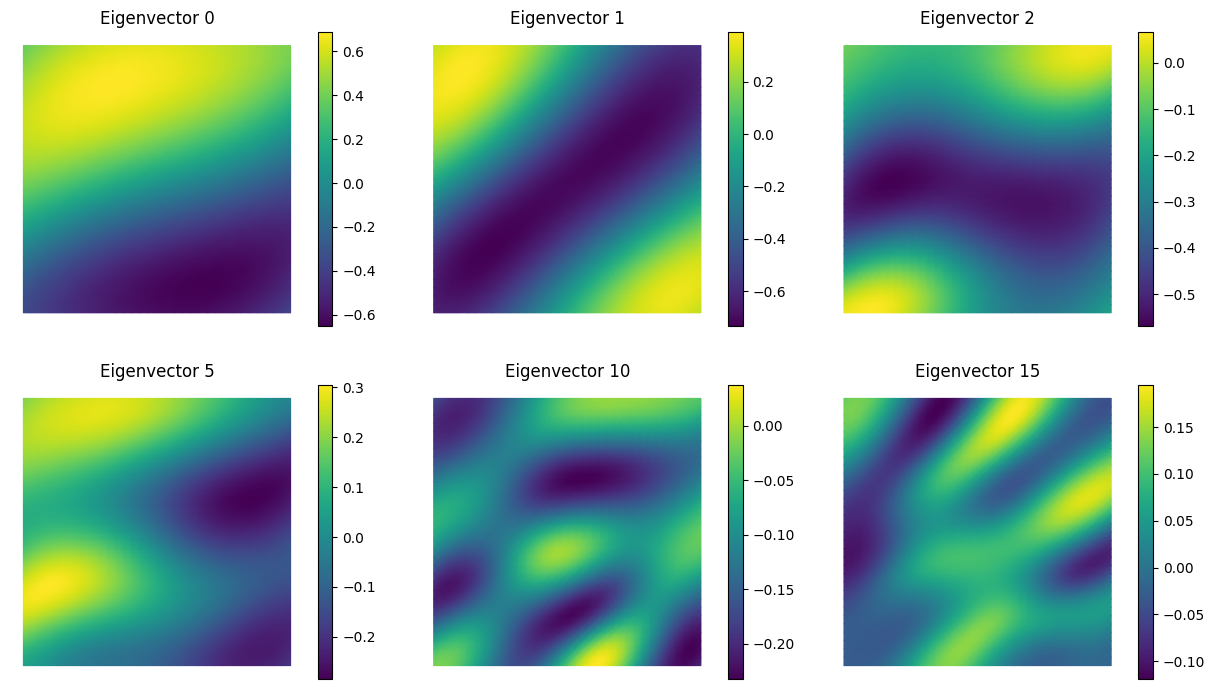

In [9]:
model.setPointForHessianEvaluations(x, gauss_newton_approx=False)
Hmisfit = hm.ReducedHessian(model, misfit_only=True)
k = 50
p = 20
print("Double Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k, p))

Omega = hm.MultiVector(x[PARAMETER], k + p)
hm.parRandom.normal_multivector(1.0, Omega)
d, U = hm.doublePassG(Hmisfit, prior.R, prior.Rsolver, Omega, k)

nu = hm.GaussianLRPosterior(prior, d, U, mean=x[PARAMETER])

plt.figure(figsize=(7, 4.5))
nb.plot_eigenvalues(d, mytitle="Generalized eigenvalues")
nb.plot_eigenvectors(Vh[PARAMETER], U, mytitle="Eigenvector", which=[0, 1, 2, 5, 10, 15])
plt.show()

## 10. Prior and posterior pointwise variance fields

Posterior trace 8.098737e-01; Prior trace 1.793521e+00; Correction trace 9.836468e-01


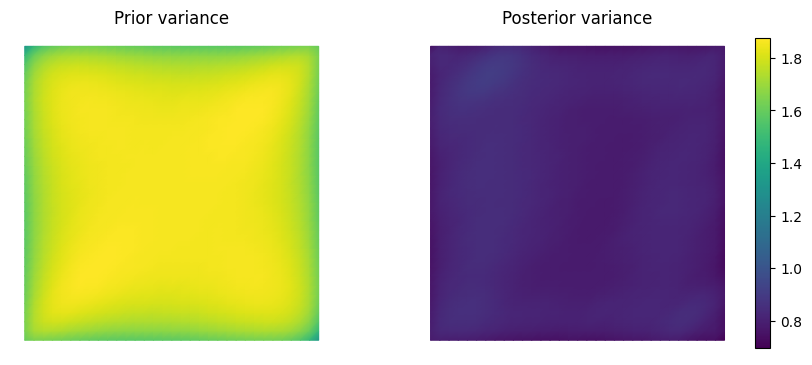

In [10]:
compute_trace = True
if compute_trace:
    post_tr, prior_tr, corr_tr = nu.trace(method="Randomized", r=200)
    print("Posterior trace {0:5e}; Prior trace {1:5e}; Correction trace {2:5e}".format(post_tr, prior_tr, corr_tr))
post_pw_variance, pr_pw_variance, corr_pw_variance = nu.pointwise_variance(method="Randomized", r=200)

nb.multi1_plot([(Vh[PARAMETER], pr_pw_variance), (Vh[PARAMETER], post_pw_variance)],
               ["Prior variance", "Posterior variance"], logscale=False)
plt.show()

## 11. Generate samples from the prior and the Laplace approximation of the posterior

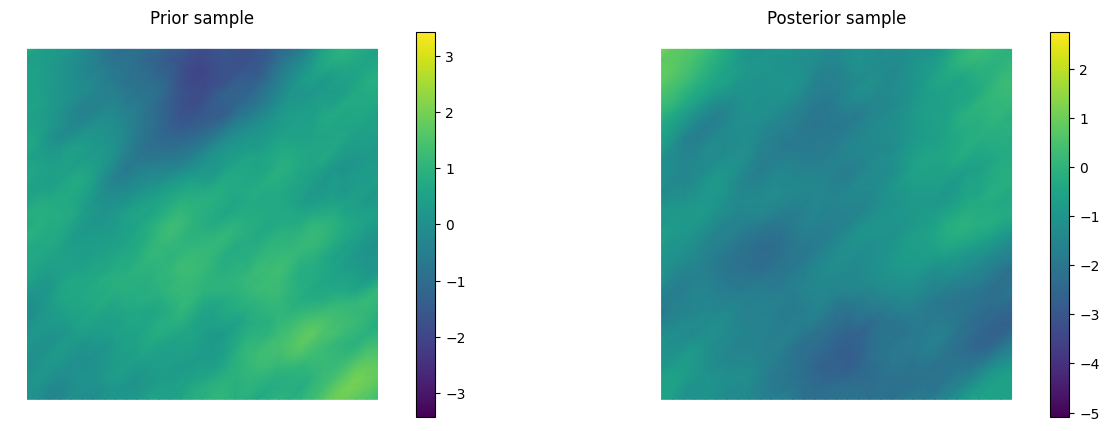

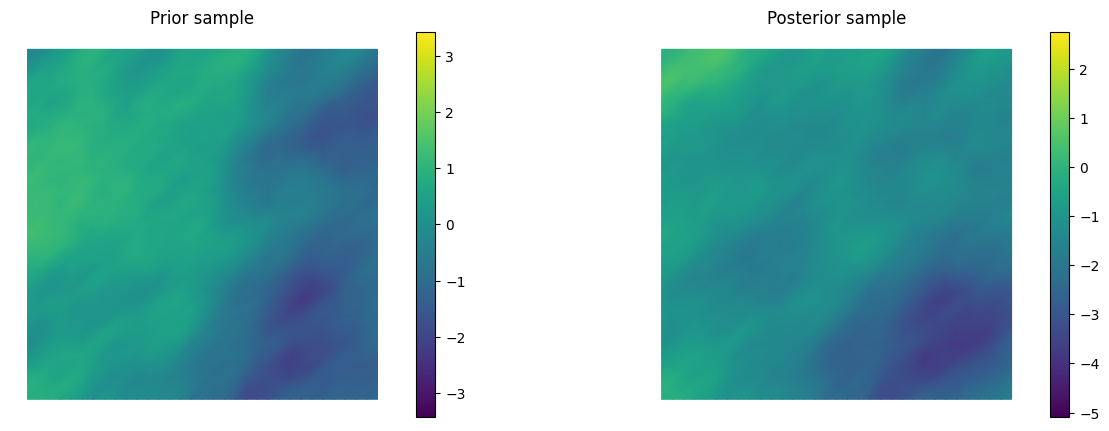

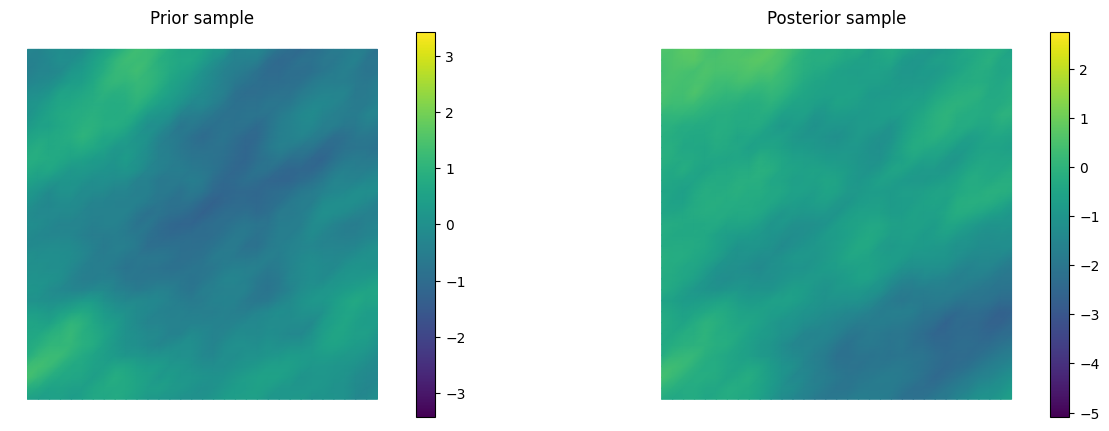

In [11]:
nsamples = 3
noise = prior.noise_vector()
s_prior = Vh[PARAMETER].vector()
s_post = Vh[PARAMETER].vector()

pr_max = 2.5 * math.sqrt(pr_pw_variance.max()) + prior.mean.max()
pr_min = -2.5 * math.sqrt(pr_pw_variance.max()) + prior.mean.min()
ps_max = 2.5 * math.sqrt(post_pw_variance.max()) + nu.mean.max()
ps_min = -2.5 * math.sqrt(post_pw_variance.max()) + nu.mean.min()

for i in range(nsamples):
    prior.sample_noise(1.0, noise)
    nu.sample(noise, s_prior, s_post)
    plt.figure(figsize=(15, 5))
    nb.plot(Vh[PARAMETER], s_prior, subplot_loc=121, mytitle="Prior sample", vmin=pr_min, vmax=pr_max)
    nb.plot(Vh[PARAMETER], s_post, subplot_loc=122, mytitle="Posterior sample", vmin=ps_min, vmax=ps_max)
    plt.show()

## 12. Define a quantity of interest

As a quantity of interest, we consider the flux through the bottom boundary $\Gamma_b$,

$$ q(m) = \int_{\Gamma_b} e^m \frac{\partial u}{\partial y} \, ds. $$

A density does not have to be a boundary integral to compute it. The flow is divergence
free and the side walls are insulated, so the same flux crosses every horizontal line
$y = c$; integrating over $c \in (0, 1)$ turns the boundary flux into a volume integral,

$$ q(m) = \int_\Omega e^m \frac{\partial u}{\partial y} \, dx, $$

which `hm.VariationalQoi` evaluates (and could differentiate) from a density of the state
and the parameter at one quadrature point.

In [12]:
def flux_density(u, m, x):
    return jnp.exp(m.val) * u.grad[1]


qoi = hm.VariationalQoi(Vh, flux_density)
print("q at the true parameter: %.5f" % qoi.eval([utrue, mtrue, None]))
print("q at the MAP point:      %.5f" % qoi.eval(x))

q at the true parameter: 0.12400
q at the MAP point:      0.27579


## 13. Compute posterior expectations using MCMC

The chain starts from a sample of the Laplace approximation and uses gpCN with step
$s = 0.3$. The first `burn_in` samples are discarded.

In [13]:
noise = prior.noise_vector()
prior.sample_noise(1.0, noise)
pr_s = model.generate_vector(PARAMETER)
post_s = model.generate_vector(PARAMETER)
nu.sample(noise, pr_s, post_s, add_mean=True)

kernel = hm.gpCNKernel(model, nu)
kernel.parameters["s"] = 0.3
chain = hm.MCMC(kernel)
chain.parameters["burn_in"] = 500
chain.parameters["number_of_samples"] = 5000
chain.parameters["print_progress"] = 5
chain.parameters["print_level"] = 1
tracer = hm.QoiTracer(chain.parameters["number_of_samples"])

start = time.time()
n_accept = chain.run(post_s, qoi, tracer)
elapsed = time.time() - start

print("Number accepted = {0}".format(n_accept))
print("E[q] = {0}".format(chain.sum_q / float(chain.parameters["number_of_samples"])))
print("%.1f s, %.1f ms per sample" % (elapsed, 1e3 * elapsed / (chain.parameters["number_of_samples"] + chain.parameters["burn_in"])))

Burning 500 samples (gpCN kernel)


   20.0% complete, acceptance ratio  63.0%


   40.0% complete, acceptance ratio  61.5%


   60.0% complete, acceptance ratio  56.7%


   80.0% complete, acceptance ratio  54.8%


...

   40.0% complete, acceptance ratio  52.2%


   60.0% complete, acceptance ratio  53.4%


   80.0% complete, acceptance ratio  52.1%


  100.0% complete, acceptance ratio  52.1%


Number accepted = 2603
E[q] = 0.4257323521381337
165.7 s, 30.1 ms per sample


## 14. How much is the chain worth?

The trace plot shows the chain's history, the histogram the marginal distribution of the
quantity of interest, and the autocorrelation how many steps it takes the chain to forget
where it was. Summing the autocorrelation gives the integrated autocorrelation time, and the
chain length divided by it is the effective sample size: the number of independent samples
the chain is worth.

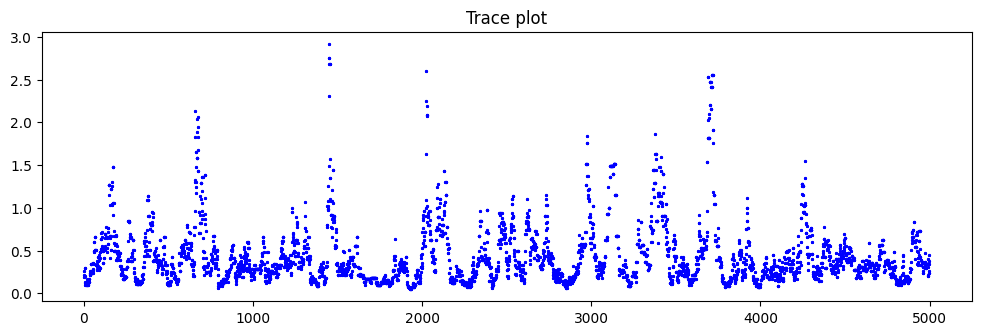

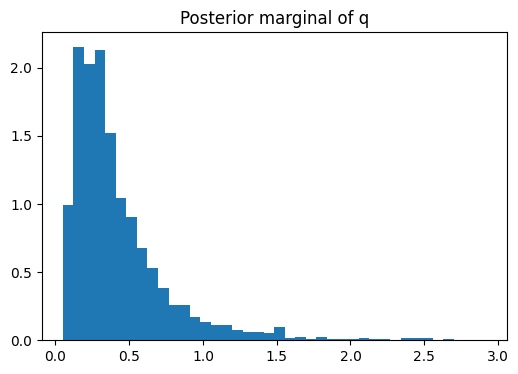

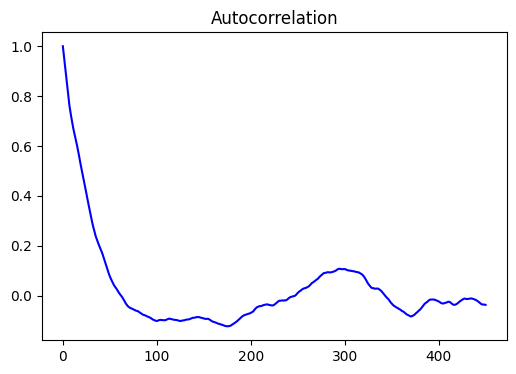

Integrated autocorrelation time (largest partial sum): 47.26674965125384
hm.chain_summary: integrated autocorrelation time 45.1, effective sample size 111 of 5000
E[q] = 0.42573 with standard error 0.03299; q(MAP) = 0.27579


In [14]:
q = tracer.trim()

plt.figure(figsize=(12, 3.5))
plt.plot(q, "*b", markersize=2)
plt.title("Trace plot")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(q, density=True, bins=40)
plt.title("Posterior marginal of q")
plt.show()


def acorr(mean_free_samples, lag, norm=1):
    return (mean_free_samples[:mean_free_samples.size - lag] * mean_free_samples[lag:]).ravel().mean() / norm


def acorr_vs_lag(samples, max_lag=500):
    mean = samples.mean()
    mean_free_samples = samples - mean
    norm = acorr(mean_free_samples, 0)
    lags = np.arange(0, max_lag + 1)
    acorrs = np.ones(max_lag + 1)
    for lag in lags[1:]:
        acorrs[lag] = acorr(mean_free_samples, lag, norm)
    return lags, acorrs


plt.figure(figsize=(6, 4))
max_lag = 450
lags, acorrs = acorr_vs_lag(q, max_lag)
plt.plot(lags, acorrs, "-b")
plt.title("Autocorrelation")
plt.show()

integrated_corr_time = 1.0 + 2.0 * np.max(acorrs.cumsum())
print("Integrated autocorrelation time (largest partial sum):", integrated_corr_time)

summary = hm.chain_summary(q)
print("hm.chain_summary: integrated autocorrelation time %.1f, effective sample size %.0f of %d"
      % (summary["iact"], summary["ess"], q.size))
print("E[q] = %.5f with standard error %.5f; q(MAP) = %.5f"
      % (summary["mean"], summary["standard_error"], qoi.eval(x)))

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `06_MCMC`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).